In [1]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
import tensorflow as tf
import random as rn
from sklearn.metrics import accuracy_score, precision_score, recall_score, log_loss, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt
import time
import pywt
from skimage.transform import resize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Reproducibility
sd = 1
os.environ['PYTHONHASHSEED'] = str(sd)
np.random.seed(sd)
rn.seed(sd)
tf.random.set_seed(sd)

# Class label structure
data_dict = {
    0: ("Healthy", ["K001", "K002", "K003", "K004", "K005"]),
    1: ("OR_Damage", ["KA04", "KA15", "KA16", "KA22", "KA30"]),
    2: ("IR_Damage", ["KI04", "KI14", "KI16", "KI18", "KI21"]),
}

# -- Stage 1 --

## Load CWRU Bearing Data and Introduce Imbalance

In [3]:
sample_limit_per_label = {0: 256000, 1: 5120, 2: 5120}


# Extract vibration signal from .mat file
def extract_signals_df(filepath, signal="vibration"):
    signal_idx = {"vibration": 6}.get(signal)
    mat = loadmat(filepath, struct_as_record=False, squeeze_me=True)
    struct = mat[next(k for k in mat if not k.startswith("__"))]
    signal_data = struct.Y[signal_idx].Data.flatten()
    return pd.DataFrame(signal_data, columns=["vibration"])


def load_and_imbalance_paderborn_data(root_dir, imbalance_ratio):
    data_dict = {
        0: ("Healthy", ["K001", "K002", "K003", "K004", "K005"]),
        1: ("OR_Damage", ["KA04", "KA15", "KA16", "KA22", "KA30"]),
        2: ("IR_Damage", ["KI04", "KI14", "KI16", "KI18", "KI21"]),
    }

    all_data = {0: [], 1: [], 2: []}

    for label, (category, folders) in data_dict.items():
        for folder in folders:
            folder_path = os.path.join(root_dir, folder)
            if not os.path.exists(folder_path):
                print(f"Missing folder: {folder_path}")
                continue

            mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]
            if not mat_files:
                print(f"No .mat files in: {folder_path}")
                continue

            file_path = os.path.join(folder_path, mat_files[0])

            try:
                df = extract_signals_df(file_path)
                df = df.iloc[:sample_limit_per_label[label]].copy()
                df["label"] = label
                all_data[label].append(df)
                print(f"Loaded {file_path} with {len(df)} samples.")
            except Exception as e:
                print(f"Error reading {file_path}: {e}")
    
            # try:
            #     df = extract_signals_df(file_path)
            #     total_samples = len(df)

            #     # Subsample fault classes
            #     if label != 0:
            #         fault_sample_limit = max(1000, total_samples // imbalance_ratio)
            #         df = df.iloc[:fault_sample_limit]

            #     df["label"] = label
            #     all_data[label].append(df)
            #     print(f"Loaded {file_path} → {len(df)} samples")

            # except Exception as e:
            #     print(f"Error reading {file_path}: {e}")

    # Combine all data
    final_df = pd.concat([df for dfs in all_data.values() for df in dfs], ignore_index=True)
    final_df.rename(columns={"vibration": "signal"}, inplace=True)
    print(f"\nCombined dataset shape: {final_df.shape}\n")
    print(final_df.head())

    # Signal grouping
    df_signals = final_df[["signal", "label"]]
    grouped_signals = [
        df_signals[df_signals["label"] == label]["signal"].values.astype(float)
        for label in sorted(df_signals["label"].unique())
    ]
    
    # Datapoints per group
    # print("\n Count of samples in each group")
    for idx, signal_array in enumerate(grouped_signals):
        class_name = data_dict[idx][0]
        print(f"Class {idx} ({class_name}) - Number of samples: {len(signal_array)}")

    return final_df, grouped_signals, data_dict


## Visualisation - Plotting class distribution and Raw vibrational data

In [4]:
# Prepare data for plotting
labels = [data_dict[label][0] for label in sorted(final_df['label'].unique())]
counts = [len(df_signals[df_signals['label'] == label]) for label in sorted(final_df['label'].unique())]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(labels, counts, color='skyblue')
plt.title('Class Distribution After Applying Imbalance')
plt.xlabel('Class Labels')
plt.ylabel('Number of Samples')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Plot vibration signals
# Plot 1000 samples from each class
num_classes_to_plot = len(grouped_signals)
plt.figure(figsize=(15, 4 * num_classes_to_plot))

for idx in range(num_classes_to_plot):
    signal_array = grouped_signals[idx]
    class_name = data_dict[idx][0]

    plt.subplot(num_classes_to_plot, 1, idx + 1)
    plt.plot(signal_array[:1000])
    plt.title(f"Class {idx} ({class_name})")
    plt.xlabel("Time Index")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'final_df' is not defined

# --- Stage 2 ---

## Generate overlapping segments

In [6]:
def extract_segments(data, samples_per_block, interval_length, ignore_points=0):
    """
    Extract segments from data using vectorized indexing.

    Args:
        data (np.ndarray): Input signal data.
        samples_per_block (int): Length of each segment.
        interval_length (int): Step size between segment starts.
        ignore_points (int): Points to ignore at start and end.

    Returns:
        np.ndarray: Array of shape (n_segments, samples_per_block).
    """
    data = np.asarray(data).flatten()
    adjusted_length = len(data) - 2 * ignore_points
    n_segments = max(0, (adjusted_length - samples_per_block) // interval_length + 1)
    if n_segments == 0:
        return np.empty((0, samples_per_block), dtype=data.dtype)

    start_indices = ignore_points + np.arange(n_segments) * interval_length
    indices = start_indices[:, None] + np.arange(samples_per_block)
    return data[indices]

## Create Overlapping segments, One hot encoding

In [7]:
def segment_signals(grouped_signals, image_shape, samples_per_block, interval_length, n_classes):
    segment_list = []
    one_hot_labels = []
    integer_labels = []

    for class_idx, signal in enumerate(grouped_signals):
        segments = extract_segments(signal, samples_per_block, interval_length)
        n_segments = segments.shape[0]

        print(f"\nClass: {class_idx} Fault Label: {data_dict[class_idx][0]}")
        print(f"Segments: {n_segments} segments")
        print(f"Sample data (first 5 elements): {segments[0][:5] if n_segments > 0 else 'Empty'}")
        
        if n_segments > 0:
            one_hot = np.zeros((n_segments, n_classes))
            one_hot[:, class_idx] = 1
            labels = np.full((n_segments, 1), class_idx)

            segment_list.append(segments)
            one_hot_labels.append(one_hot)
            integer_labels.append(labels)

    return segment_list, one_hot_labels, integer_labels


# --- Stage 3 ---


## Time-Based Train-Test Split

In [8]:
def time_train_test_split(segment_list, one_hot_labels, integer_labels, train_ratio=0.8, n_classes=3):
    """
    Perform time-based class-wise train-test split for Paderborn dataset.

    Args:
        segment_list (List[np.ndarray]): List of segment arrays per class.
        one_hot_labels (List[np.ndarray]): One-hot encoded label arrays.
        integer_labels (List[np.ndarray]): Integer label arrays.
        train_ratio (float): Fraction of data for training.
        n_classes (int): Number of classes.

    Returns:
        tuple: (X_train, X_test, Y_train, Y_test, y_train, y_test)
    """
    X_train_list, X_test_list = [], []
    Y_train_list, Y_test_list = [], []
    y_train_list, y_test_list = [], []

    image_shape = (40, 40)

    for class_idx, (segments, one_hot, integer) in enumerate(zip(segment_list, one_hot_labels, integer_labels)):
        n_segments = segments.shape[0]
        train_size = int(n_segments * train_ratio)
        train_segments = segments[:train_size]
        test_segments = segments[train_size:]

        print(f"\nClass {class_idx} (Label {class_idx}):")
        print(f"Train segments: {train_segments.shape[0]}")
        print(f"Test segments: {test_segments.shape[0]}")

        if train_segments.shape[0] > 0:
            X_train_list.append(train_segments)
            Y_train_list.append(one_hot[:train_size])
            y_train_list.append(integer[:train_size])

        if test_segments.shape[0] > 0:
            X_test_list.append(test_segments)
            Y_test_list.append(one_hot[train_size:])
            y_test_list.append(integer[train_size:])

    X_train = np.vstack(X_train_list) if X_train_list else np.empty((0, 1600))
    X_test = np.vstack(X_test_list) if X_test_list else np.empty((0, 1600))
    Y_train = np.vstack(Y_train_list) if Y_train_list else np.empty((0, n_classes))
    Y_test = np.vstack(Y_test_list) if Y_test_list else np.empty((0, n_classes))
    y_train = np.vstack(y_train_list) if y_train_list else np.empty((0, 1))
    y_test = np.vstack(y_test_list) if y_test_list else np.empty((0, 1))

    X_2D_train = X_train.reshape([-1, image_shape[0], image_shape[1], 1])
    X_2D_test = X_test.reshape([-1, image_shape[0], image_shape[1], 1])

    print(f"\nFinal X_train shape: {X_2D_train.shape}")
    print(f"Final Y_train shape: {Y_train.shape}")
    print(f"Final y_train shape: {y_train.shape}")
    print(f"Final X_test shape: {X_2D_test.shape}")
    print(f"Final Y_test shape: {Y_test.shape}")
    print(f"Final y_test shape: {y_test.shape}")

    return X_2D_train, X_2D_test, Y_train, Y_test, y_train, y_test


In [9]:
root_dir = './Paderborn_PreCase1_Data'
imbalance_ratio = 50
interval_length = 290
samples_per_block = 1600
train_ratio = 0.8
n_classes = 3


# Stage 1: Load and apply imbalance
final_df, grouped_signals, data_dict = load_and_imbalance_paderborn_data(root_dir, imbalance_ratio)

# Stage 2: Segment signals
segments, one_hot_labels, integer_labels = segment_signals(grouped_signals, image_shape=(40, 40), samples_per_block=1600, interval_length=290, n_classes=3)


# Stage 3: Train-test split
X_2D_train, X_2D_test, Y_train, Y_test, y_label_train, y_label_test = time_train_test_split(
    segments, one_hot_labels, integer_labels, train_ratio, n_classes
)

# # Split into training and test sets (80% train, 20% test)
# X_train_split, X_test_split, y_train_positional_split, y_test_positional_split = train_test_split(
#     X_train, y_train_positional, test_size=0.2, random_state=sd, stratify=y_train)

# X_1D_train = X_train_split.reshape([-1, samples_per_block, 1])
# X_1D_test = X_test_split.reshape([-1, samples_per_block, 1])
# input_shape = (samples_per_block, 1)   # Reshaped input

Loaded ./Paderborn_PreCase1_Data/K001/N15_M07_F04_K001_13.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K002/N09_M07_F10_K002_2.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K003/N09_M07_F10_K003_1.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K004/N09_M07_F10_K004_2.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K005/N09_M07_F10_K005_1.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/KA04/N09_M07_F10_KA04_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA15/N09_M07_F10_KA15_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA16/N09_M07_F10_KA16_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA22/N09_M07_F10_KA22_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA30/N09_M07_F10_KA30_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KI04/N09_M07_F10_KI04_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KI14/N09_M07_F10_KI14_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_D

# Model definition

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
input_shape = (40, 40, 1)
print(f"X_2D_train shape: {X_2D_train.shape}") 
print(f"X_2D_test shape: {X_2D_test.shape}")  
print(f"Y_train shape: {Y_train.shape}") 
print(f"Y_test shape: {Y_test.shape}") 
print(f"Y_train shape: {y_label_train.shape}") 
print(f"Y_test shape: {y_label_test.shape}")  

class CNN_2D():
    def __init__(self):
        self.model = self.CreateModel()

    def CreateModel(self):
        model = models.Sequential([
            layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape= (40, 40, 1)),
            layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
            layers.MaxPool2D((2, 2), padding='same'),
            layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
            layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
            layers.MaxPool2D((2, 2), padding='same'),
            layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
            layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
            layers.MaxPool2D((2, 2), padding='same'),
            layers.Flatten(),
            layers.Dense(100, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(96, activation='relu'),
            layers.Dense(3, activation='softmax')
            
            # layers.Conv2D(filters=16, kernel_size=(3,3), padding='same',activation='relu', input_shape=(40,40,1)),
            # layers.MaxPool2D(pool_size=(2,2), padding='same'),
            # layers.Conv2D(filters=32, kernel_size=(3,3), padding ='same',activation='relu'),
            # layers.MaxPool2D(pool_size=(2,2), padding='same'),
            # layers.Conv2D(filters=64, kernel_size=(3,3),padding ='same', activation='relu'),
            # layers.MaxPool2D(pool_size=(2,2), padding='same'),
            # layers.Conv2D(filters=128, kernel_size=(3,3),padding ='same', activation='relu'),
            # layers.MaxPool2D(pool_size=(2,2), padding='same'),
            # layers.Flatten(),
            # layers.Dense(100,activation='relu'),
            # layers.Dense(50,activation='relu'),
            # layers.Dense(3),
            # layers.Softmax()

            # layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', activation='relu', input_shape=input_shape),
            # layers.BatchNormalization(),
            # layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            # layers.Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            # layers.BatchNormalization(),
            # layers.MaxPool2D(pool_size=(2,2), padding='same'),

            # layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            # layers.BatchNormalization(),
            # layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            # layers.Conv2D(filters=128, kernel_size=(3,3), strides=1, padding ='same', activation='relu'),
            # layers.BatchNormalization(),
            # layers.MaxPool2D(pool_size=(2,2), padding='same'),

            # # layers.Flatten(),
            # # layers.Dense(100,activation='relu'),
            # # layers.Dense(50,activation='relu'),
            # # layers.Dense(3, activation='softmax')

            # layers.GlobalAveragePooling2D(),
            # layers.Dense(64, activation='relu'),
            # layers.Dropout(0.3),
            # layers.Dense(3, activation='softmax')
        ])
        model.compile(
            optimizer='adam',
            loss=tf.keras.losses.CategoricalCrossentropy(),
            metrics=['accuracy']
        )
        return model

X_2D_train shape: (3659, 40, 40, 1)
X_2D_test shape: (916, 40, 40, 1)
Y_train shape: (3659, 3)
Y_test shape: (916, 3)
Y_train shape: (3659, 1)
Y_test shape: (916, 1)


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9392 - loss: 0.3789
Epoch 1: val_accuracy improved from -inf to 0.96448, saving model to Paderborn_results/Paderborn_CNN2D-OL-Latest/best_model_fold_1.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - accuracy: 0.9394 - loss: 0.3772 - val_accuracy: 0.9645 - val_loss: 0.1013
Epoch 2/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9709 - loss: 0.0837
Epoch 2: val_accuracy improved from 0.96448 to 0.98361, saving model to Paderborn_results/Paderborn_CNN2D-OL-Latest/best_model_fold_1.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.9710 - loss: 0.0834 - val_accuracy: 0.9836 - val_loss: 0.0577
Epoch 3/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9825 - loss: 0.0569
Epoch 3: val_accuracy did not improve from 0.98361
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.9825 - loss: 0.0569 - val_accuracy: 0.9822 - val_loss: 0.0504
Epoch 4/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9790 - loss: 0.0468
Epoch 4: val_accuracy did not improve from 0.98361
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.9790 - loss: 0.0469 - val_accuracy: 0.9768 - val_loss: 0.0447
Epoch 5/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9822 - loss: 0.0433
Epoch 5: val_accuracy did not improve from 0.98361
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9822 - loss: 0.0433 - val_accuracy: 0.9836 - val_loss: 0.0473
Epoch 6/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9865 - loss: 0.0326
Epoch 6: val_accuracy did not impro

92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.9847 - loss: 0.0459 - val_accuracy: 0.9863 - val_loss: 0.0257
Epoch 8/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9842 - loss: 0.0236
Epoch 8: val_accuracy did not improve from 0.98634
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.9842 - loss: 0.0238 - val_accuracy: 0.8156 - val_loss: 0.4008
Epoch 9/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9727 - loss: 0.1124
Epoch 9: val_accuracy did not improve from 0.98634
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.9728 - loss: 0.1119 - val_accuracy: 0.9822 - val_loss: 0.0300
Epoch 10/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9814 - loss: 0.0269
Epoch 10: val_accuracy did not improve from 0.98634
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - accuracy: 0.9814 - loss: 0.0269 - val_accuracy: 0.9850 - val_loss: 0.0283
Epoch 11/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9837 - loss: 0.0246
Epoch 11: val_accuracy did not im

92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9859 - loss: 0.0221 - val_accuracy: 0.9918 - val_loss: 0.0190
Epoch 22/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9924 - loss: 0.0179
Epoch 22: val_accuracy did not improve from 0.99180
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - accuracy: 0.9923 - loss: 0.0179 - val_accuracy: 0.9877 - val_loss: 0.0265
Epoch 23/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9817 - loss: 0.0805
Epoch 23: val_accuracy did not improve from 0.99180
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.9817 - loss: 0.0805 - val_accuracy: 0.9822 - val_loss: 0.0344
Epoch 24/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9876 - loss: 0.0228
Epoch 24: val_accuracy did not improve from 0.99180
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.9875 - loss: 0.0229 - val_accuracy: 0.9850 - val_loss: 0.0264
Epoch 25/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9918 - loss: 0.0222
Epoch 25: val_accuracy did n

Best model saved at: Paderborn_results/Paderborn_CNN2D-OL-Latest/best_model_fold_1.h5
Best model loaded successfully!
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


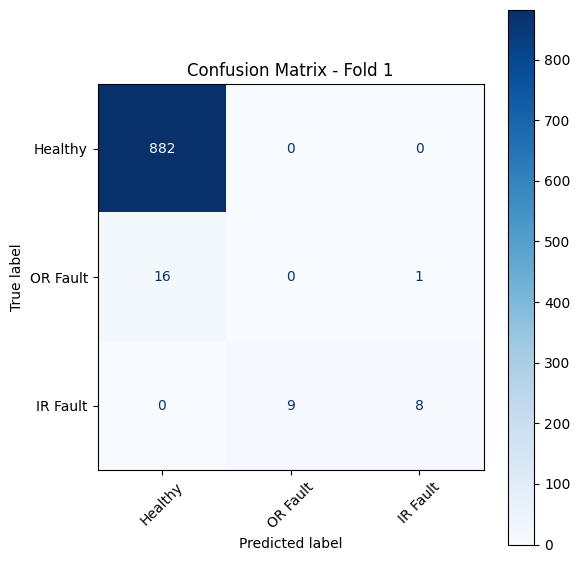

Saved confusion matrix for Fold 1 at: Paderborn_results/Paderborn_CNN2D-OL-Latest/confusion_matrices/confusion_matrix_fold_1.png
Epoch 1/200


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9204 - loss: 0.3450
Epoch 1: val_accuracy improved from -inf to 0.96448, saving model to Paderborn_results/Paderborn_CNN2D-OL-Latest/best_model_fold_2.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.9208 - loss: 0.3435 - val_accuracy: 0.9645 - val_loss: 0.0767
Epoch 2/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9706 - loss: 0.0858
Epoch 2: val_accuracy improved from 0.96448 to 0.98224, saving model to Paderborn_results/Paderborn_CNN2D-OL-Latest/best_model_fold_2.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.9706 - loss: 0.0857 - val_accuracy: 0.9822 - val_loss: 0.0522
Epoch 3/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9846 - loss: 0.0573
Epoch 3: val_accuracy did not improve from 0.98224
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.9845 - loss: 0.0573 - val_accuracy: 0.9781 - val_loss: 0.0425
Epoch 4/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9824 - loss: 0.0614
Epoch 4: val_accuracy did not improve from 0.98224
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.9823 - loss: 0.0613 - val_accuracy: 0.9822 - val_loss: 0.0403
Epoch 5/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9847 - loss: 0.0445
Epoch 5: val_accuracy did not improve from 0.98224
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - accuracy: 0.9847 - loss: 0.0445 - val_accuracy: 0.9822 - val_loss: 0.0398
Epoch 6/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.9846 - loss: 0.0374
Epoch 6: val_accuracy did not 

...

92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.9887 - loss: 0.0209 - val_accuracy: 0.9945 - val_loss: 0.0191
Epoch 23/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9846 - loss: 0.0446
Epoch 23: val_accuracy did not improve from 0.99454
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.9846 - loss: 0.0446 - val_accuracy: 0.9877 - val_loss: 0.0252
Epoch 24/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9865 - loss: 0.0238
Epoch 24: val_accuracy did not improve from 0.99454
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9865 - loss: 0.0238 - val_accuracy: 0.9904 - val_loss: 0.0166
Epoch 25/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9909 - loss: 0.0175
Epoch 25: val_accuracy did not improve from 0.99454
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.9909 - loss: 0.0176 - val_accuracy: 0.9945 - val_loss: 0.0163
Epoch 26/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9904 - loss: 0.0179
Epoch 26: val_accuracy did 

92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.9930 - loss: 0.0114 - val_accuracy: 0.9959 - val_loss: 0.0069
Epoch 67/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9969 - loss: 0.0092
Epoch 67: val_accuracy did not improve from 0.99590
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.9969 - loss: 0.0092 - val_accuracy: 0.9932 - val_loss: 0.0168
Epoch 68/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9969 - loss: 0.0081
Epoch 68: val_accuracy did not improve from 0.99590
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.9969 - loss: 0.0082 - val_accuracy: 0.9945 - val_loss: 0.0168
Epoch 69/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9968 - loss: 0.0072
Epoch 69: val_accuracy did not improve from 0.99590
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9968 - loss: 0.0072 - val_accuracy: 0.9959 - val_loss: 0.0112
Epoch 70/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9974 - loss: 0.0079
Epoch 70: val_accuracy impr

92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.9973 - loss: 0.0081 - val_accuracy: 0.9986 - val_loss: 0.0061
Epoch 71/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9968 - loss: 0.0077
Epoch 71: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.9968 - loss: 0.0077 - val_accuracy: 0.9973 - val_loss: 0.0059
Epoch 72/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9965 - loss: 0.0075
Epoch 72: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.9965 - loss: 0.0076 - val_accuracy: 0.9986 - val_loss: 0.0052
Epoch 73/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9968 - loss: 0.0073
Epoch 73: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.9967 - loss: 0.0074 - val_accuracy: 0.9973 - val_loss: 0.0061
Epoch 74/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9946 - loss: 0.0089
Epoch 74: val_accuracy did

92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.9981 - loss: 0.0060 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 100/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9951 - loss: 0.0109
Epoch 100: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.9950 - loss: 0.0110 - val_accuracy: 0.9973 - val_loss: 0.0049
Epoch 101/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9968 - loss: 0.0070
Epoch 101: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.9968 - loss: 0.0070 - val_accuracy: 0.9986 - val_loss: 0.0038
Epoch 102/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9981 - loss: 0.0059
Epoch 102: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.9981 - loss: 0.0060 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 103/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9988 - loss: 0.0040
Epoch 103: val_a

Best model saved at: Paderborn_results/Paderborn_CNN2D-OL-Latest/best_model_fold_2.h5
Best model loaded successfully!
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


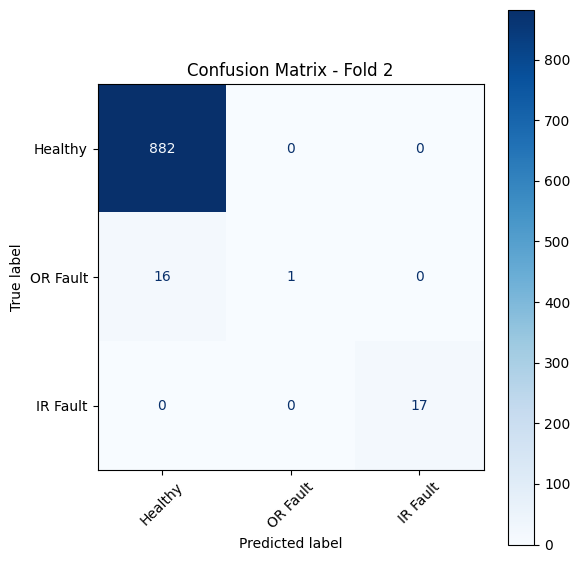

Saved confusion matrix for Fold 2 at: Paderborn_results/Paderborn_CNN2D-OL-Latest/confusion_matrices/confusion_matrix_fold_2.png
Epoch 1/200


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9189 - loss: 0.3674
Epoch 1: val_accuracy improved from -inf to 0.96311, saving model to Paderborn_results/Paderborn_CNN2D-OL-Latest/best_model_fold_3.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - accuracy: 0.9197 - loss: 0.3642 - val_accuracy: 0.9631 - val_loss: 0.0961
Epoch 2/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9717 - loss: 0.0801
Epoch 2: val_accuracy improved from 0.96311 to 0.98224, saving model to Paderborn_results/Paderborn_CNN2D-OL-Latest/best_model_fold_3.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.9717 - loss: 0.0800 - val_accuracy: 0.9822 - val_loss: 0.0540
Epoch 3/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9824 - loss: 0.0518
Epoch 3: val_accuracy improved from 0.98224 to 0.98361, saving model to Paderborn_results/Paderborn_CNN2D-OL-Latest/best_model_fold_3.h5


...

92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.9942 - loss: 0.0189 - val_accuracy: 0.9945 - val_loss: 0.0194
Epoch 43/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9927 - loss: 0.0176
Epoch 43: val_accuracy did not improve from 0.99454
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.9926 - loss: 0.0178 - val_accuracy: 0.9645 - val_loss: 0.2738
Epoch 44/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9846 - loss: 0.0671
Epoch 44: val_accuracy did not improve from 0.99454
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - accuracy: 0.9846 - loss: 0.0664 - val_accuracy: 0.9904 - val_loss: 0.0210
Epoch 45/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9927 - loss: 0.0167
Epoch 45: val_accuracy did not improve from 0.99454
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.9927 - loss: 0.0167 - val_accuracy: 0.9891 - val_loss: 0.0206
Epoch 46/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9918 - loss: 0.0166
Epoch 46: val_accuracy di

92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.9943 - loss: 0.0137 - val_accuracy: 0.9973 - val_loss: 0.0136
Epoch 52/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9969 - loss: 0.0107
Epoch 52: val_accuracy did not improve from 0.99727
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.9969 - loss: 0.0108 - val_accuracy: 0.9727 - val_loss: 0.0695
Epoch 53/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9825 - loss: 0.0454
Epoch 53: val_accuracy did not improve from 0.99727
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9825 - loss: 0.0453 - val_accuracy: 0.9918 - val_loss: 0.0271
Epoch 54/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9894 - loss: 0.0223
Epoch 54: val_accuracy did not improve from 0.99727
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - accuracy: 0.9894 - loss: 0.0223 - val_accuracy: 0.9959 - val_loss: 0.0149
Epoch 55/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9960 - loss: 0.0139
Epoch 55: val_accuracy did not

92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.9976 - loss: 0.0072 - val_accuracy: 0.9986 - val_loss: 0.0084
Epoch 80/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9978 - loss: 0.0077
Epoch 80: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.9978 - loss: 0.0078 - val_accuracy: 0.9973 - val_loss: 0.0083
Epoch 81/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9971 - loss: 0.0099
Epoch 81: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.9970 - loss: 0.0100 - val_accuracy: 0.9891 - val_loss: 0.0216
Epoch 82/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9906 - loss: 0.0182
Epoch 82: val_accuracy did not improve from 0.99863
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.9906 - loss: 0.0183 - val_accuracy: 0.9891 - val_loss: 0.0207
Epoch 83/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9910 - loss: 0.0176
Epoch 83: val_accuracy di

92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.9950 - loss: 0.0083 - val_accuracy: 1.0000 - val_loss: 0.0053
Epoch 120/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9972 - loss: 0.0058
Epoch 120: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 168ms/step - accuracy: 0.9971 - loss: 0.0058 - val_accuracy: 1.0000 - val_loss: 0.0048
Epoch 121/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9968 - loss: 0.0047
Epoch 121: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.9968 - loss: 0.0047 - val_accuracy: 0.9986 - val_loss: 0.0039
Epoch 122/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9975 - loss: 0.0037
Epoch 122: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.9975 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 123/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9956 - loss: 0.0045
Epoch 123: va

Best model loaded successfully!
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


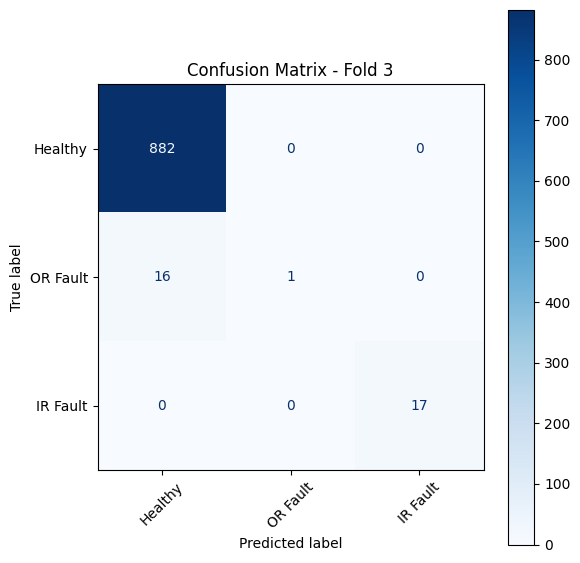

Saved confusion matrix for Fold 3 at: Paderborn_results/Paderborn_CNN2D-OL-Latest/confusion_matrices/confusion_matrix_fold_3.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9588 - loss: 0.4506
Epoch 1: val_accuracy improved from -inf to 0.96311, saving model to Paderborn_results/Paderborn_CNN2D-OL-Latest/best_model_fold_4.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 136ms/step - accuracy: 0.9589 - loss: 0.4487 - val_accuracy: 0.9631 - val_loss: 0.1325
Epoch 2/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9688 - loss: 0.0954
Epoch 2: val_accuracy improved from 0.96311 to 0.98087, saving model to Paderborn_results/Paderborn_CNN2D-OL-Latest/best_model_fold_4.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.9688 - loss: 0.0952 - val_accuracy: 0.9809 - val_loss: 0.0496
Epoch 3/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9852 - loss: 0.0595
Epoch 3: val_accuracy did not improve from 0.98087
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.9852 - loss: 0.0595 - val_accuracy: 0.9809 - val_loss: 0.0449
Epoch 4/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9847 - loss: 0.0480
Epoch 4: val_accuracy did not improve from 0.98087
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.9846 - loss: 0.0480 - val_accuracy: 0.9781 - val_loss: 0.0382
Epoch 5/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9833 - loss: 0.0694
Epoch 5: val_accuracy did not improve from 0.98087
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - accuracy: 0.9833 - loss: 0.0692 - val_accuracy: 0.9795 - val_loss: 0.0303
Epoch 6/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9857 - loss: 0.0285 
Epoch 6: val_accuracy impro

...

92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 128ms/step - accuracy: 0.9856 - loss: 0.0274 - val_accuracy: 0.9850 - val_loss: 0.0253
Epoch 11/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9860 - loss: 0.0235
Epoch 11: val_accuracy did not improve from 0.98497
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.9860 - loss: 0.0235 - val_accuracy: 0.9850 - val_loss: 0.0250
Epoch 12/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.9849 - loss: 0.0234
Epoch 12: val_accuracy did not improve from 0.98497
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 0.9848 - loss: 0.0234 - val_accuracy: 0.9809 - val_loss: 0.0345
Epoch 13/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9825 - loss: 0.0325
Epoch 13: val_accuracy did not improve from 0.98497
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.9825 - loss: 0.0325 - val_accuracy: 0.9836 - val_loss: 0.0258
Epoch 14/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9860 - loss: 0.0234
Epoch 14: val_accura

92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.9877 - loss: 0.0216 - val_accuracy: 0.9918 - val_loss: 0.0273
Epoch 17/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9868 - loss: 0.0204
Epoch 17: val_accuracy did not improve from 0.99180
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - accuracy: 0.9868 - loss: 0.0205 - val_accuracy: 0.9822 - val_loss: 0.0243
Epoch 18/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9901 - loss: 0.0209
Epoch 18: val_accuracy did not improve from 0.99180
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 128ms/step - accuracy: 0.9901 - loss: 0.0210 - val_accuracy: 0.9891 - val_loss: 0.0290
Epoch 19/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9862 - loss: 0.0263
Epoch 19: val_accuracy did not improve from 0.99180
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.9862 - loss: 0.0263 - val_accuracy: 0.9822 - val_loss: 0.0398
Epoch 20/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9904 - loss: 0.0184
Epoch 20: val_accura

92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 118ms/step - accuracy: 0.9938 - loss: 0.0130 - val_accuracy: 0.9932 - val_loss: 0.0223
Epoch 36/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9918 - loss: 0.0130
Epoch 36: val_accuracy did not improve from 0.99317
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.9918 - loss: 0.0131 - val_accuracy: 0.9932 - val_loss: 0.0173
Epoch 37/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9913 - loss: 0.0138
Epoch 37: val_accuracy did not improve from 0.99317
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 140ms/step - accuracy: 0.9913 - loss: 0.0138 - val_accuracy: 0.9918 - val_loss: 0.0648
Epoch 38/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9925 - loss: 0.0217
Epoch 38: val_accuracy improved from 0.99317 to 0.99454, saving model to Paderborn_results/Paderborn_CNN2D-OL-Latest/best_model_fold_4.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.9925 - loss: 0.0216 - val_accuracy: 0.9945 - val_loss: 0.0128
Epoch 39/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9933 - loss: 0.0118
Epoch 39: val_accuracy did not improve from 0.99454
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.9932 - loss: 0.0118 - val_accuracy: 0.9932 - val_loss: 0.0167
Epoch 40/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9929 - loss: 0.0109
Epoch 40: val_accuracy did not improve from 0.99454
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.9929 - loss: 0.0110 - val_accuracy: 0.9932 - val_loss: 0.0163
Epoch 41/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9947 - loss: 0.0100
Epoch 41: val_accuracy did not improve from 0.99454
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.9947 - loss: 0.0101 - val_accuracy: 0.9932 - val_loss: 0.0179
Epoch 42/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9928 - loss: 0.0160
Epoch 42: val_accura

Best model loaded successfully!
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step


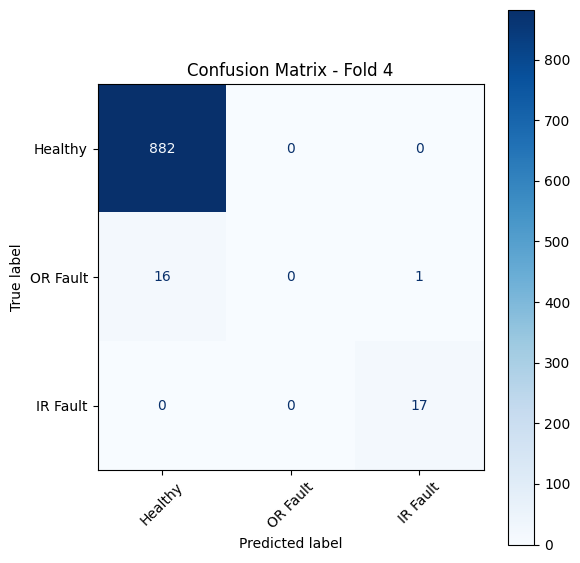

Saved confusion matrix for Fold 4 at: Paderborn_results/Paderborn_CNN2D-OL-Latest/confusion_matrices/confusion_matrix_fold_4.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulari

Epoch 1/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9311 - loss: 0.3203
Epoch 1: val_accuracy improved from -inf to 0.96443, saving model to Paderborn_results/Paderborn_CNN2D-OL-Latest/best_model_fold_5.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.9317 - loss: 0.3176 - val_accuracy: 0.9644 - val_loss: 0.0659
Epoch 2/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9724 - loss: 0.0675
Epoch 2: val_accuracy improved from 0.96443 to 0.98222, saving model to Paderborn_results/Paderborn_CNN2D-OL-Latest/best_model_fold_5.h5


92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.9724 - loss: 0.0676 - val_accuracy: 0.9822 - val_loss: 0.0824
Epoch 3/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9824 - loss: 0.0617
Epoch 3: val_accuracy improved from 0.98222 to 0.98358, saving model to Paderborn_results/Paderborn_CNN2D-OL-Latest/best_model_fold_5.h5


...

92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.9886 - loss: 0.0233 - val_accuracy: 0.9863 - val_loss: 0.0244
Epoch 11/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9837 - loss: 0.0324
Epoch 11: val_accuracy did not improve from 0.98632
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.9837 - loss: 0.0325 - val_accuracy: 0.9863 - val_loss: 0.0243
Epoch 12/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9867 - loss: 0.0222
Epoch 12: val_accuracy did not improve from 0.98632
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.9867 - loss: 0.0222 - val_accuracy: 0.9863 - val_loss: 0.0235
Epoch 13/200
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9821 - loss: 0.0845
Epoch 13: val_accuracy did not improve from 0.98632
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.9820 - loss: 0.0839 - val_accuracy: 0.9863 - val_loss: 0.0253
Epoch 14/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9879 - loss: 0.0223
Epoch 14: val_accura

92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.9844 - loss: 0.0226 - val_accuracy: 0.9904 - val_loss: 0.0238
Epoch 17/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9879 - loss: 0.0206
Epoch 17: val_accuracy did not improve from 0.99042
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.9878 - loss: 0.0207 - val_accuracy: 0.9836 - val_loss: 0.0242
Epoch 18/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9847 - loss: 0.0245
Epoch 18: val_accuracy did not improve from 0.99042
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.9847 - loss: 0.0245 - val_accuracy: 0.9877 - val_loss: 0.0240
Epoch 19/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9847 - loss: 0.0218
Epoch 19: val_accuracy did not improve from 0.99042
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - accuracy: 0.9846 - loss: 0.0218 - val_accuracy: 0.9863 - val_loss: 0.0234
Epoch 20/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9883 - loss: 0.0212
Epoch 20: val_accura

92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.9903 - loss: 0.0158 - val_accuracy: 0.9932 - val_loss: 0.0153
Epoch 33/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9903 - loss: 0.0172
Epoch 33: val_accuracy did not improve from 0.99316
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.9903 - loss: 0.0172 - val_accuracy: 0.9932 - val_loss: 0.0153
Epoch 34/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9920 - loss: 0.0155
Epoch 34: val_accuracy did not improve from 0.99316
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.9920 - loss: 0.0155 - val_accuracy: 0.9932 - val_loss: 0.0151
Epoch 35/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9920 - loss: 0.0154
Epoch 35: val_accuracy did not improve from 0.99316
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.9920 - loss: 0.0155 - val_accuracy: 0.9932 - val_loss: 0.0152
Epoch 36/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9915 - loss: 0.0144
Epoch 36: val_accura

92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.9942 - loss: 0.0109 - val_accuracy: 0.9945 - val_loss: 0.0130
Epoch 46/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9862 - loss: 0.0400
Epoch 46: val_accuracy did not improve from 0.99453
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.9862 - loss: 0.0401 - val_accuracy: 0.9932 - val_loss: 0.0140
Epoch 47/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9917 - loss: 0.0142
Epoch 47: val_accuracy did not improve from 0.99453
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.9917 - loss: 0.0142 - val_accuracy: 0.9918 - val_loss: 0.0166
Epoch 48/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9924 - loss: 0.0118
Epoch 48: val_accuracy did not improve from 0.99453
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.9924 - loss: 0.0119 - val_accuracy: 0.9932 - val_loss: 0.0131
Epoch 49/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9925 - loss: 0.0114
Epoch 49: val_accura

Best model loaded successfully!
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


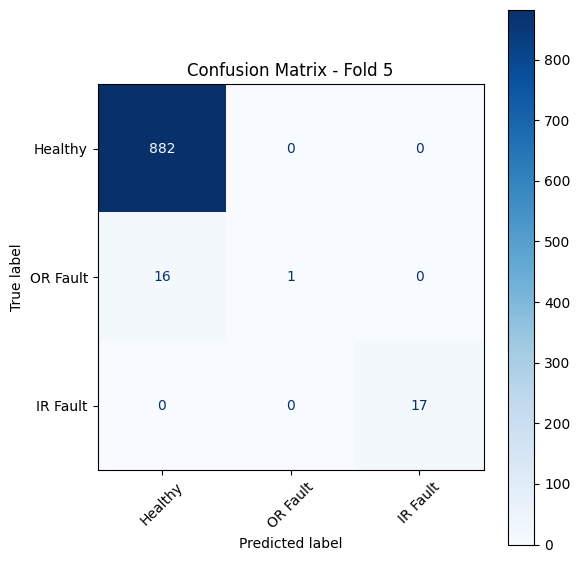

Saved confusion matrix for Fold 5 at: Paderborn_results/Paderborn_CNN2D-OL-Latest/confusion_matrices/confusion_matrix_fold_5.png


In [11]:
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential, load_model
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, balanced_accuracy_score

# Condition mapping
condition_map = {
    0: "Healthy",
    1: "OR Fault",
    2: "IR Fault"
}

# Training with k-fold validation
foldername = "Paderborn_results/Paderborn_CNN2D-OL-Latest/"
kSplits = 5
accuracy_1D = []
precision_1D = []
recall_1D = []
f1_1D = []
precision_1D_macro = []
recall_1D_macro = []
f1_1D_macro = []
log_loss_1D = []
balanced_accuracy_1D = []
accuracy_1D_test = []
precision_1D_test = []
recall_1D_test = []
f1_1D_test = []
precision_1D_test_macro = []
recall_1D_test_macro = []
f1_1D_test_macro = []
log_loss_1D_test = []
balanced_accuracy_1D_test = []

# Initialize arrays for validation predictions across folds
n_train_samples = Y_train.shape[0]
pred_all_val = np.zeros((n_train_samples, 3))  # Store validation predictions
y_val_true = np.zeros((n_train_samples, 3))    # Store true validation labels
kfold_test_len = []                             # Store size of each validation fold
fl1 = 0

early_stop = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
kfold = StratifiedKFold(n_splits=kSplits, random_state=42, shuffle=True)

# Train the model with k-fold cross-validation
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_2D_train, y_label_train.flatten())):
    checkpoint_filepath = foldername + f"best_model_fold_{fold+1}.h5"
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    Classification_2D = CNN_2D()
    history = Classification_2D.model.fit(
        X_2D_train[train_idx], Y_train[train_idx],
        validation_data=(X_2D_train[val_idx], Y_train[val_idx]),
        epochs=200,
        verbose=1,
        callbacks=[checkpoint, early_stop]
    )
    print(f"Best model saved at: {checkpoint_filepath}")
    CNN_2D_best_model = load_model(checkpoint_filepath)
    print("Best model loaded successfully!")

    # Store validation predictions
    fl2 = fl1 + len(val_idx)
    pred_all_val[fl1:fl2, :] = CNN_2D_best_model.predict(X_2D_train[val_idx])
    y_val_true[fl1:fl2, :] = Y_train[val_idx]
    kfold_test_len.append(fl2 - fl1)
    fl1 = fl2

    # Train set metrics (for the current fold's training data)
    y_pred_proba_train = CNN_2D_best_model.predict(X_2D_train[train_idx])
    y_pred_train = np.argmax(y_pred_proba_train, axis=1)
    y_true_train = np.argmax(Y_train[train_idx], axis=1)

    accuracy_1D.append(accuracy_score(y_true_train, y_pred_train))
    precision_1D.append(precision_score(y_true_train, y_pred_train, average='weighted'))
    recall_1D.append(recall_score(y_true_train, y_pred_train, average='weighted'))
    f1_1D.append(f1_score(y_true_train, y_pred_train, average='weighted'))
    precision_1D_macro.append(precision_score(y_true_train, y_pred_train, average='macro'))
    recall_1D_macro.append(recall_score(y_true_train, y_pred_train, average='macro'))
    f1_1D_macro.append(f1_score(y_true_train, y_pred_train, average='macro'))
    log_loss_1D.append(log_loss(Y_train[train_idx], y_pred_proba_train))
    balanced_accuracy_1D.append(balanced_accuracy_score(y_true_train, y_pred_train))

    # Test set metrics
    y_pred_proba_test = CNN_2D_best_model.predict(X_2D_test)
    y_pred_test = np.argmax(y_pred_proba_test, axis=1)
    y_true_test = np.argmax(Y_test, axis=1)

     # Compute confusion matrix
    cm = confusion_matrix(y_true_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[condition_map[i] for i in range(3)])
    
    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
    plt.title(f'Confusion Matrix - Fold {fold + 1}')
    plt.grid(False)
    plt.tight_layout()
    
    # Save path
    save_dir = os.path.join(foldername, "confusion_matrices")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"confusion_matrix_fold_{fold + 1}.png")
    
    # Save and show
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved confusion matrix for Fold {fold + 1} at: {save_path}")

    accuracy_1D_test.append(accuracy_score(y_true_test, y_pred_test))
    precision_1D_test.append(precision_score(y_true_test, y_pred_test, average='weighted'))
    recall_1D_test.append(recall_score(y_true_test, y_pred_test, average='weighted'))
    f1_1D_test.append(f1_score(y_true_test, y_pred_test, average='weighted'))
    precision_1D_test_macro.append(precision_score(y_true_test, y_pred_test, average='macro'))
    recall_1D_test_macro.append(recall_score(y_true_test, y_pred_test, average='macro'))
    f1_1D_test_macro.append(f1_score(y_true_test, y_pred_test, average='macro'))
    log_loss_1D_test.append(log_loss(Y_test, y_pred_proba_test))
    balanced_accuracy_1D_test.append(balanced_accuracy_score(y_true_test, y_pred_test))

In [12]:
# Print average metrics across folds
print("\nAverage Training Metrics Across Folds:")
print(f"Accuracy: {np.mean(accuracy_1D):.4f} ± {np.std(accuracy_1D):.4f}")
print(f"Precision: {np.mean(precision_1D):.4f} ± {np.std(precision_1D):.4f}")
print(f"Recall: {np.mean(recall_1D):.4f} ± {np.std(recall_1D):.4f}")
print(f"F1 Score: {np.mean(f1_1D):.4f} ± {np.std(f1_1D):.4f}")
print(f"Precision-Macro: {np.mean(precision_1D_macro):.4f} ± {np.std(precision_1D_macro):.4f}")
print(f"Recall-Macro: {np.mean(recall_1D_macro):.4f} ± {np.std(recall_1D_macro):.4f}")
print(f"F1 Score-Macro: {np.mean(f1_1D_macro):.4f} ± {np.std(f1_1D_macro):.4f}")
print(f"Log Loss: {np.mean(log_loss_1D):.4f} ± {np.std(log_loss_1D):.4f}")
print(f"Balanced Accuracy: {np.mean(balanced_accuracy_1D):.4f} ± {np.std(balanced_accuracy_1D):.4f}")

print("\nAverage Test Metrics Across Folds:")
print(f"Accuracy: {np.mean(accuracy_1D_test):.4f} ± {np.std(accuracy_1D_test):.4f}")
print(f"Precision: {np.mean(precision_1D_test):.4f} ± {np.std(precision_1D_test):.4f}")
print(f"Recall: {np.mean(recall_1D_test):.4f} ± {np.std(recall_1D_test):.4f}")
print(f"F1 Score: {np.mean(f1_1D_test):.4f} ± {np.std(f1_1D_test):.4f}")
print(f"Precision-Macro: {np.mean(precision_1D_test_macro):.4f} ± {np.std(precision_1D_test_macro):.4f}")
print(f"Recall-Macro: {np.mean(recall_1D_test_macro):.4f} ± {np.std(recall_1D_test_macro):.4f}")
print(f"F1 Score-Macro: {np.mean(f1_1D_test_macro):.4f} ± {np.std(f1_1D_test_macro):.4f}")
print(f"Log Loss: {np.mean(log_loss_1D_test):.4f} ± {np.std(log_loss_1D_test):.4f}")
print(f"Balanced Accuracy: {np.mean(balanced_accuracy_1D_test):.4f} ± {np.std(balanced_accuracy_1D_test):.4f}")

# Distribution printing (from previous request)
unique, counts = np.unique(np.argmax(Y_train, axis=1), return_counts=True)
df_train_orig = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique],
    'Blocks': counts
})
print("\nBlocks per class in X_train:")
print(df_train_orig.to_string(index=False))

train_classes = np.argmax(Y_train, axis=1)
unique_train, counts_train = np.unique(train_classes, return_counts=True)
df_train = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_train],
    'Blocks': counts_train
})
print("\nX_train_split and Y_train distribution:")
print(df_train.to_string(index=False))

test_classes = np.argmax(Y_test, axis=1)
unique_test, counts_test = np.unique(test_classes, return_counts=True)
df_test = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_test],
    'Blocks': counts_test
})
print("\nX_test_split and Y_test distribution:")
print(df_test.to_string(index=False))

print("\ny_train_split distribution (assumed):")
print(df_train.to_string(index=False))
print("\ny_test_split distribution (assumed):")
print(df_test.to_string(index=False))


Average Training Metrics Across Folds:
Accuracy: 0.9948 ± 0.0033
Precision: 0.9954 ± 0.0029
Recall: 0.9948 ± 0.0033
F1 Score: 0.9947 ± 0.0034
Precision-Macro: 0.9151 ± 0.0537
Recall-Macro: 0.9043 ± 0.0612
F1 Score-Macro: 0.9021 ± 0.0633
Log Loss: 0.0105 ± 0.0061
Balanced Accuracy: 0.9043 ± 0.0612

Average Test Metrics Across Folds:
Accuracy: 0.9801 ± 0.0043
Precision: 0.9748 ± 0.0099
Recall: 0.9801 ± 0.0043
F1 Score: 0.9725 ± 0.0036
Precision-Macro: 0.8496 ± 0.1770
Recall-Macro: 0.6431 ± 0.0768
F1 Score-Macro: 0.6583 ± 0.0640
Log Loss: 0.2562 ± 0.0299
Balanced Accuracy: 0.6431 ± 0.0768

Blocks per class in X_train:
Condition  Blocks
  Healthy    3527
 OR Fault      66
 IR Fault      66

X_train_split and Y_train distribution:
Condition  Blocks
  Healthy    3527
 OR Fault      66
 IR Fault      66

X_test_split and Y_test distribution:
Condition  Blocks
  Healthy     882
 OR Fault      17
 IR Fault      17

y_train_split distribution (assumed):
Condition  Blocks
  Healthy    3527
 OR F

In [13]:
# Create DataFrame from per-fold metrics
kSplits=5
metrics_df = pd.DataFrame({
    'Fold': np.arange(1, kSplits + 1),
    
    'Train Accuracy (%)': np.array(accuracy_1D) * 100,
    'Test Accuracy (%)': np.array(accuracy_1D_test) * 100,

    'Train Precision (%)': np.array(precision_1D) * 100,
    'Test Precision (%)': np.array(precision_1D_test) * 100,

    'Train Recall (%)': np.array(recall_1D) * 100,
    'Test Recall (%)': np.array(recall_1D_test) * 100,

    'Train F1-score (%)': np.array(f1_1D) * 100,
    'Test F1-score (%)': np.array(f1_1D_test) * 100,

    'Train Precision-Macro (%)': np.array(precision_1D_macro) * 100,
    'Test Precision-Macro (%)': np.array(precision_1D_test_macro) * 100,

    'Train Recall-Macro (%)': np.array(recall_1D_macro) * 100,
    'Test Recall-Macro (%)': np.array(recall_1D_test_macro) * 100,

    'Train F1-score (%)': np.array(f1_1D_macro) * 100,
    'Test F1-score (%)': np.array(f1_1D_test_macro) * 100,

    'Train Log Loss': log_loss_1D,
    'Test Log Loss': log_loss_1D_test,

    'Train Balanced Accuracy (%)': np.array(balanced_accuracy_1D) * 100,
    'Test Balanced Accuracy (%)': np.array(balanced_accuracy_1D_test) * 100,
})

metrics_df

,Fold,Train Accuracy (%),Test Accuracy (%),Train Precision (%),Test Precision (%),Train Recall (%),Test Recall (%),Train F1-score (%),Test F1-score (%),Train Precision-Macro (%),Test Precision-Macro (%),Train Recall-Macro (%),Test Recall-Macro (%),Train Log Loss,Test Log Loss,Train Balanced Accuracy (%),Test Balanced Accuracy (%)
0,1,99.043389,97.161572,99.074918,96.222291,99.043389,97.161572,82.231801,53.546528,82.970346,62.369051,82.389937,49.019608,0.020009,0.252596,82.389937,49.019608
1,2,99.965835,98.253275,99.966468,98.284397,99.965835,98.253275,99.371013,70.070745,99.382716,99.406088,99.371069,68.627451,0.003503,0.274313,99.371069,68.627451
2,3,99.658353,98.253275,99.660586,98.284397,99.658353,98.253275,93.650218,70.070745,93.681917,99.406088,93.662313,68.627451,0.004412,0.199365,93.662313,68.627451
3,4,99.180048,98.144105,99.438980,96.325397,99.180048,98.144105,83.993902,65.414660,89.473684,64.220902,84.905660,66.666667,0.012982,0.277187,84.905660,66.666667
4,5,99.556011,98.253275,99.568279,98.284397,99.556011,98.253275,91.805667,70.070745,92.049808,99.406088,91.823899,68.627451,0.011669,0.277662,91.823899,68.627451


In [16]:
## turn into excel
metrics_df.to_excel(os.path.join(foldername, "Imbalanced_Paderborn.xlsx"), index=False)

In [14]:
# Compute average metrics across folds
average_metrics = metrics_df.mean(numeric_only=True).round(2)


# Safely assign 'Average' to the Fold column (overwrite if it exists)
average_row = average_metrics.to_frame().T
average_row['Fold'] = 'Average'

# Move 'Fold' to the front if needed
cols = ['Fold'] + [col for col in average_row.columns if col != 'Fold']
average_row = average_row[cols]

# Append to original metrics_df
metrics_df = pd.concat([metrics_df, average_row], ignore_index=True)

# Print
print("\n📋 Metrics Summary Including Fold-wise and Average:")
metrics_df



📋 Metrics Summary Including Fold-wise and Average:


,Fold,Train Accuracy (%),Test Accuracy (%),Train Precision (%),Test Precision (%),Train Recall (%),Test Recall (%),Train F1-score (%),Test F1-score (%),Train Precision-Macro (%),Test Precision-Macro (%),Train Recall-Macro (%),Test Recall-Macro (%),Train Log Loss,Test Log Loss,Train Balanced Accuracy (%),Test Balanced Accuracy (%)
0,1,99.043389,97.161572,99.074918,96.222291,99.043389,97.161572,82.231801,53.546528,82.970346,62.369051,82.389937,49.019608,0.020009,0.252596,82.389937,49.019608
1,2,99.965835,98.253275,99.966468,98.284397,99.965835,98.253275,99.371013,70.070745,99.382716,99.406088,99.371069,68.627451,0.003503,0.274313,99.371069,68.627451
2,3,99.658353,98.253275,99.660586,98.284397,99.658353,98.253275,93.650218,70.070745,93.681917,99.406088,93.662313,68.627451,0.004412,0.199365,93.662313,68.627451
3,4,99.180048,98.144105,99.438980,96.325397,99.180048,98.144105,83.993902,65.414660,89.473684,64.220902,84.905660,66.666667,0.012982,0.277187,84.905660,66.666667
4,5,99.556011,98.253275,99.568279,98.284397,99.556011,98.253275,91.805667,70.070745,92.049808,99.406088,91.823899,68.627451,0.011669,0.277662,91.823899,68.627451
5,Average,99.480000,98.010000,99.540000,97.480000,99.480000,98.010000,90.210000,65.830000,91.510000,84.960000,90.430000,64.310000,0.010000,0.260000,90.430000,64.310000


In [ ]:
def ConfusionMatrix(Model, X, y):
    y_pred = np.argmax(Model.predict(X), axis=1)
    ConfusionMat = confusion_matrix(np.argmax(y, axis=1), y_pred)
    return ConfusionMat
    
model_path = os.path.join(foldername, f"best_model_fold_3.h5")
print(f"\nEvaluating model: {model_path}")
CNN_2D_best_model = load_model(model_path)

plt.figure(6)
plt.title('Confusion Matrix - CNN 2D Test')
sns.heatmap(ConfusionMatrix(CNN_2D_best_model, X_2D_test, Y_test), annot=True, fmt='d', annot_kws={"fontsize":8}, cmap="YlGnBu")
plt.show()
